# Assignment 3
### - *Aidan Robin*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('life_expectancy.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_').str.replace('/', '_')
df = df.drop(columns=['unnamed:_0'])
print(df.shape)
df.head()

(1649, 20)


,countrystatus,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Outlier Detection

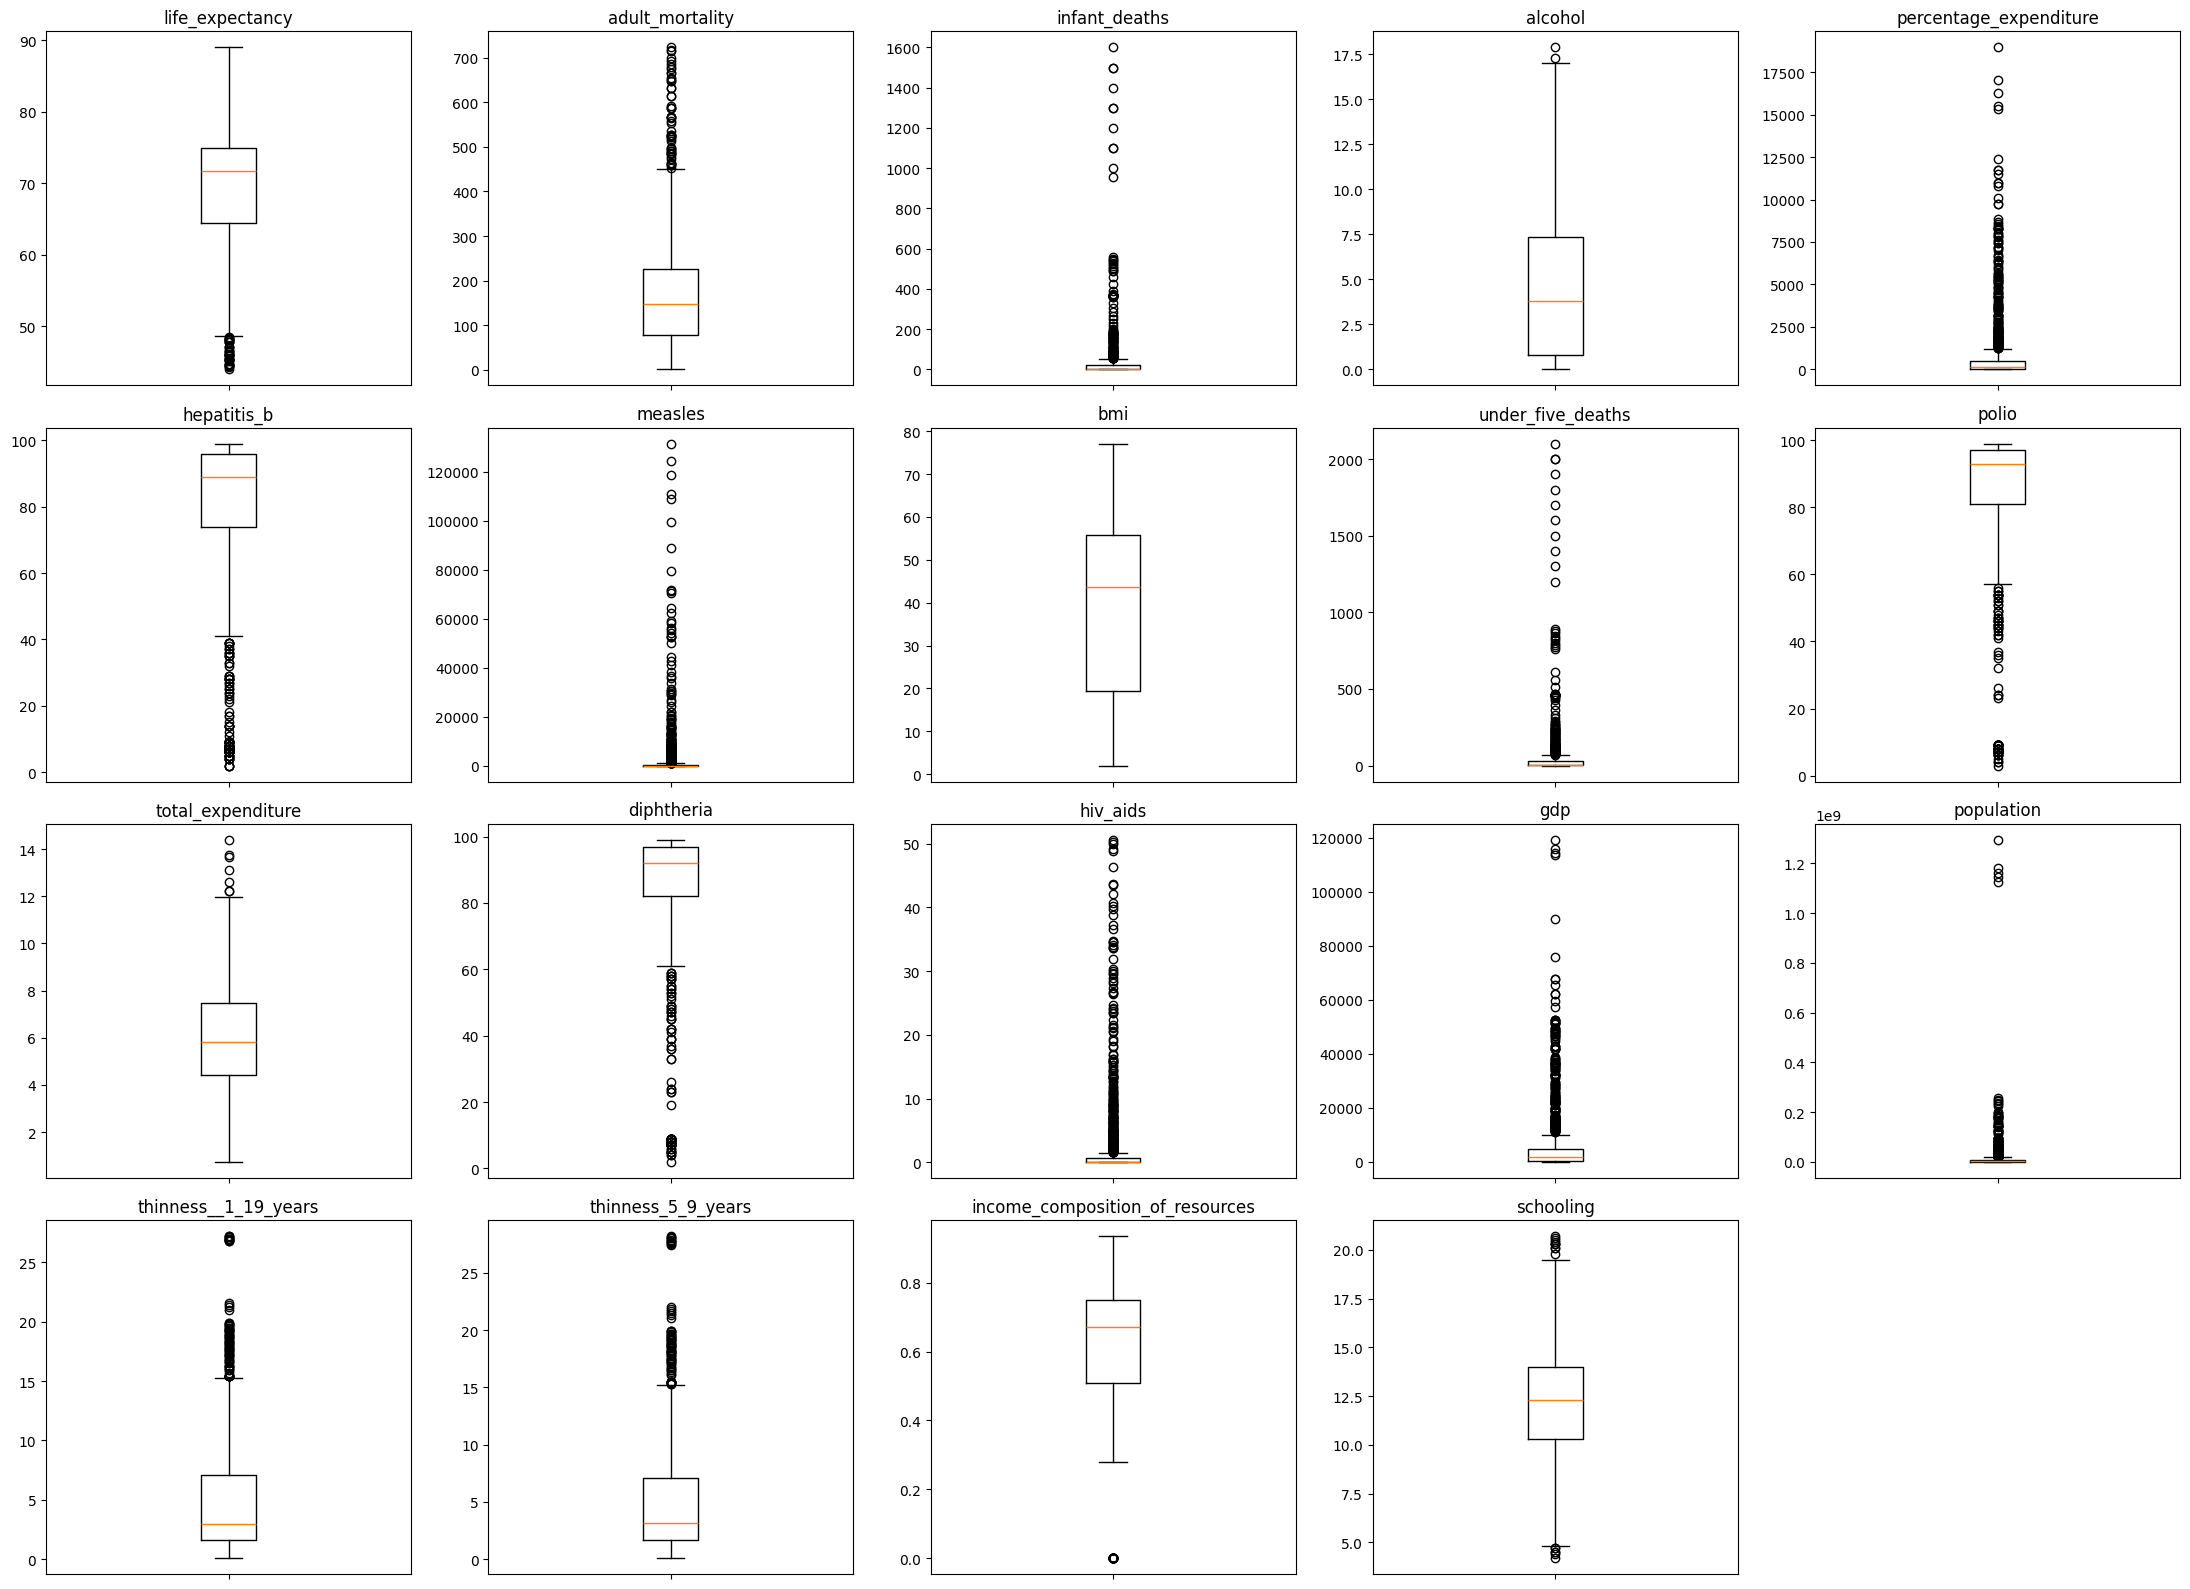

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### Outlier Decision & Justification

The box plots reveal that many features contain values flagged as statistical outliers by the IQR rule (1.5× IQR). However, we choose to keep all outliers for the following reasons:

1. Many outlier values represent real-world extremes. For example, countries with very high HIV/AIDS mortality, extremely large populations or near-zero GDP per capita are genuine data points
2. Several features (measles, infant_deaths, under_five_deaths, population) are naturally right-skewed with extreme upper tails. These values are valid and informative for the model.
3. The dataset has only 1,649 rows. Dropping hundreds of rows would remove lots of data
4. Rather than dropping outliers, we will apply transformations to heavily skewed features. This compresses extreme values without discarding any data.


## Centering & Scaling
### Histograms of Continuous Features


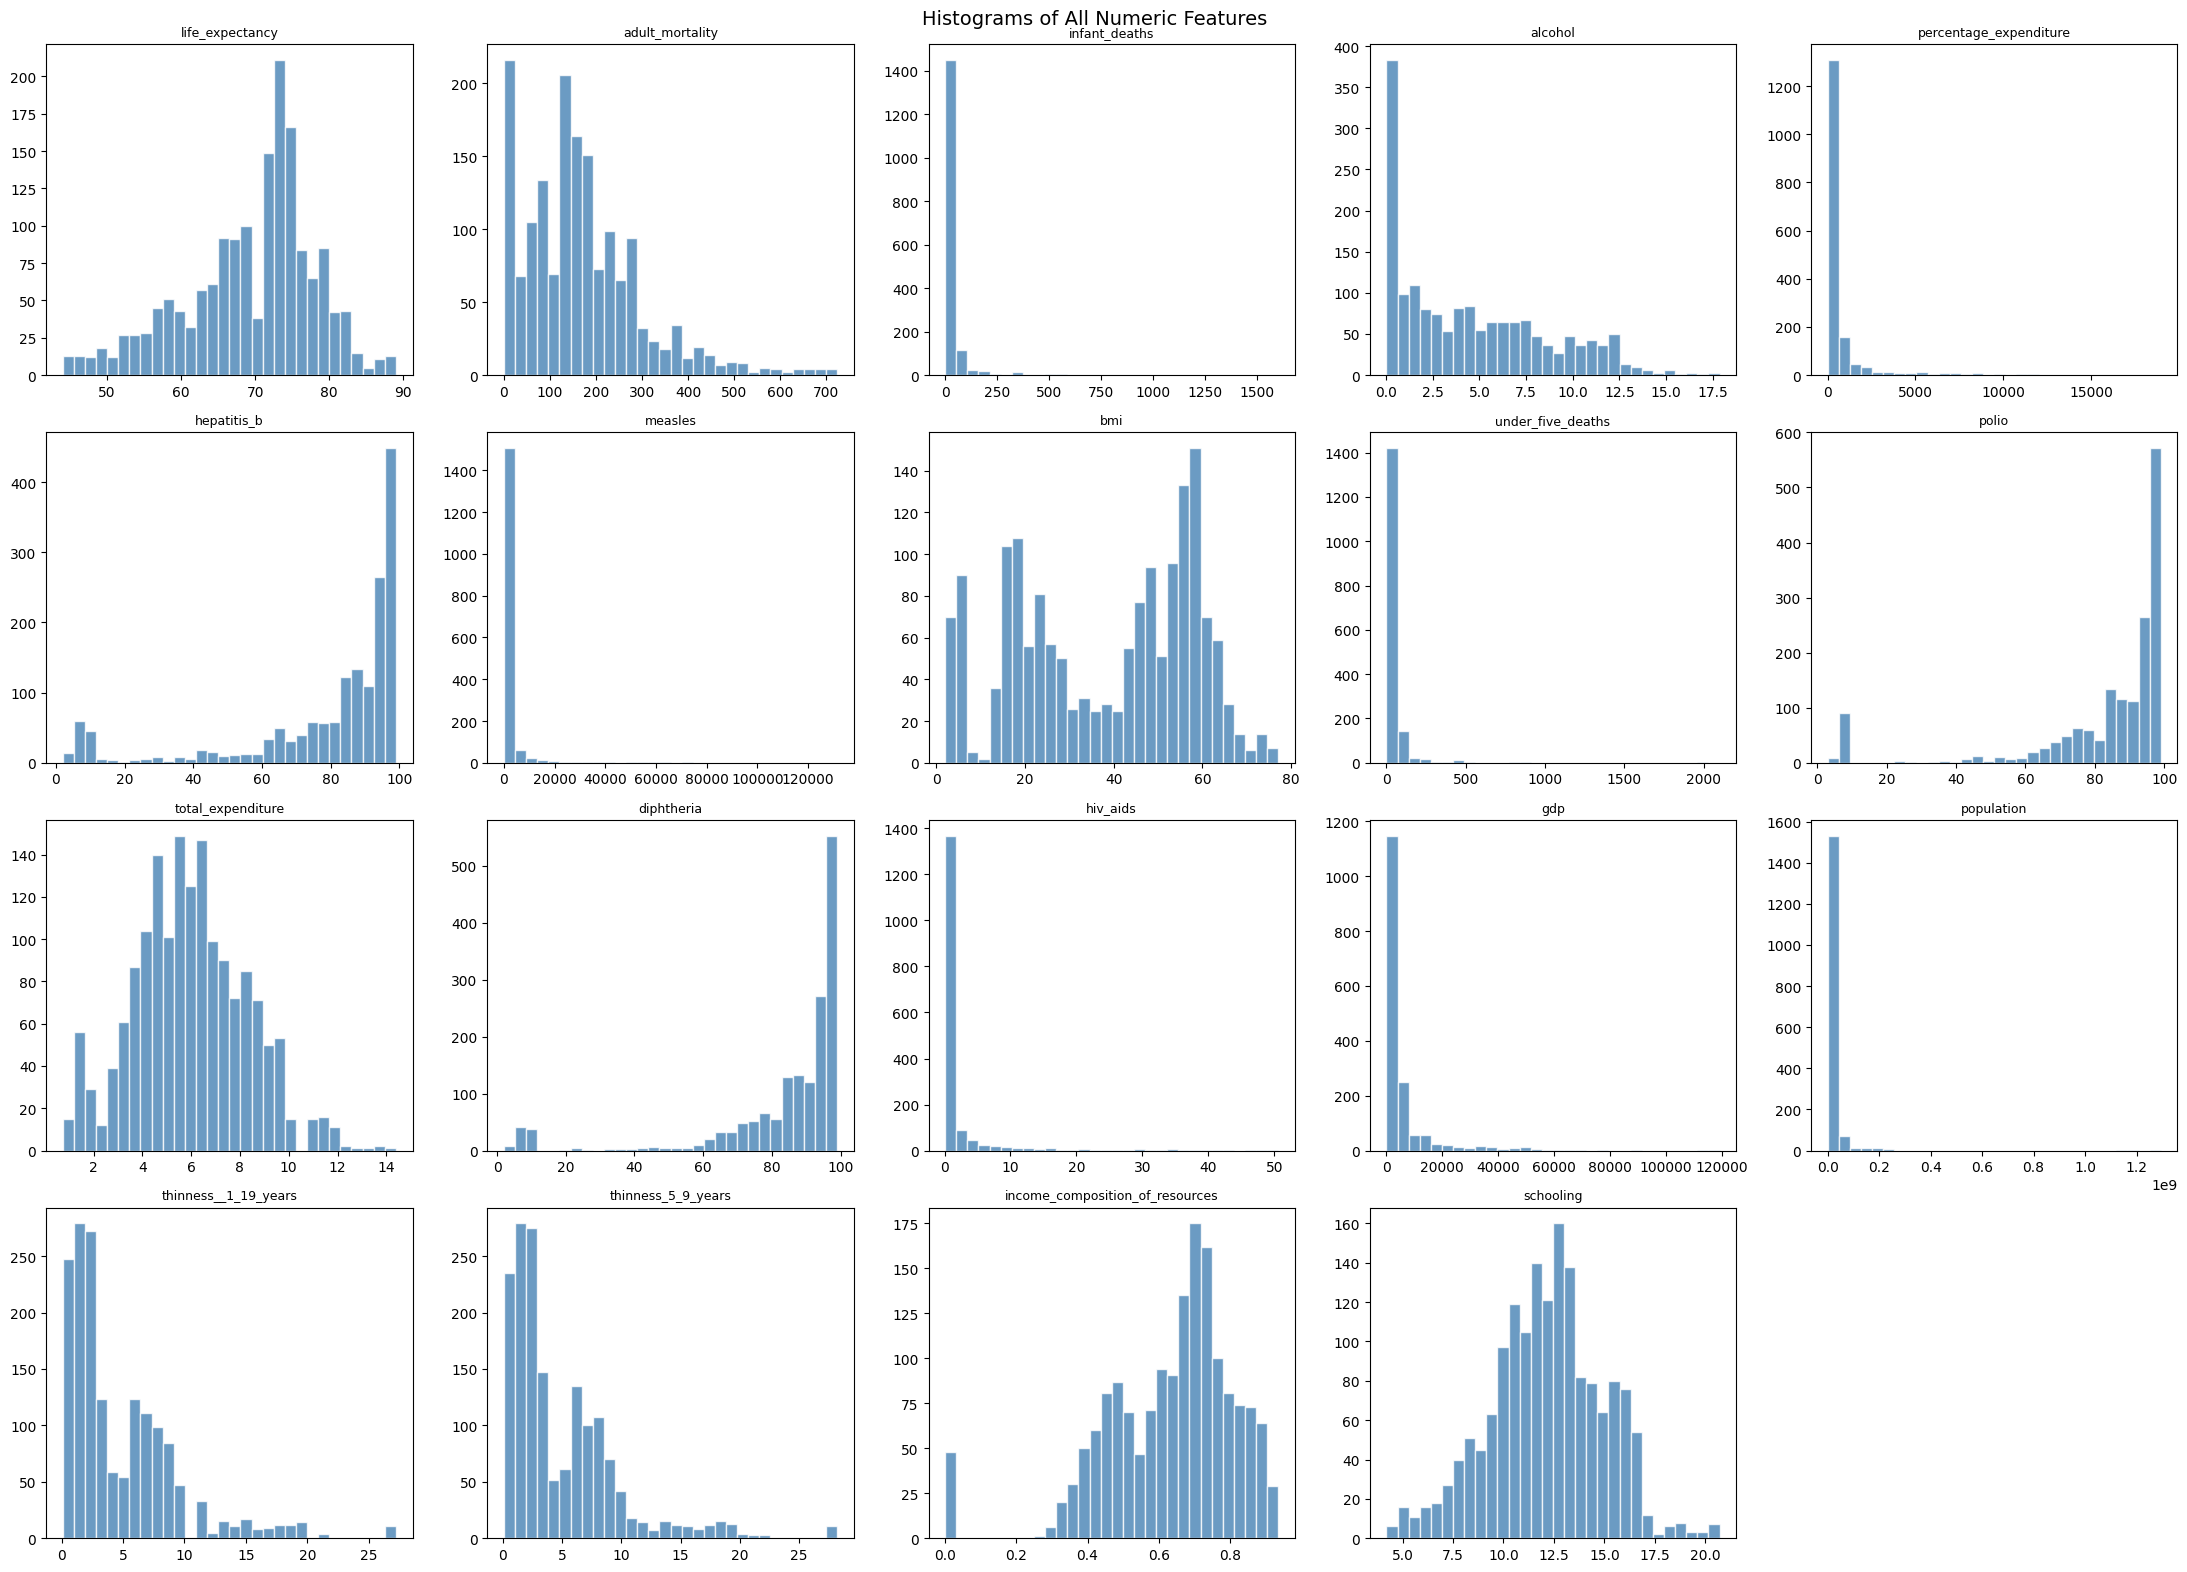

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Histograms of All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

### Scaling Justification

The histograms show that the features have vastly different scales and units. It is necessary to scale and center the data to make it easier to work with.

I've decide to use standard scaling to center/scale the data, which will be done using StandardScaler from skleran. This is appropriate because it condenses data points on large scales to a z-score.

## 4. Data Transformation


In [6]:
right_skewed = ['infant_deaths','measles','under_five_deaths','gdp',
                'population','percentage_expenditure','hiv_aids']

for col in right_skewed:
    df[f'log_{col}'] = np.log1p(df[col])

### Transformation Justification

Seven features exhibited severe right-skewness.These features had very long right tails driven by a small number of countries with extreme values.

To tranform these values, I used log tranformation. After dointg the tranformation, the distributions become more symmetric and bell-shaped. 

The other features were already roughly symmetric and did not require transformation. 

The variable **life_expectancy** was not transformed, as that is thre response variable.


## 5. Statistical Assumptions of Linear Regression

Linear regression relies on the assumptions of **normality, linearity, and independence**.

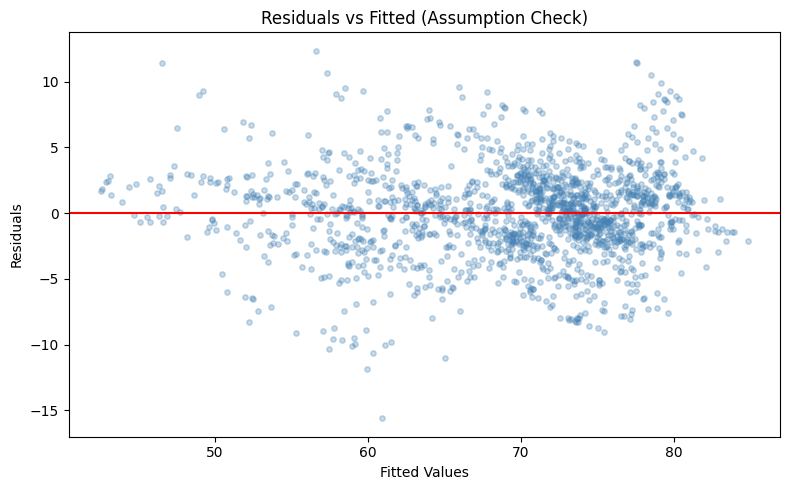

Shapiro-Wilk p-value (sample n=500): 0.0000


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
check_feats = ['adult_mortality','log_hiv_aids','income_composition_of_resources',
               'schooling','bmi','log_gdp','diphtheria']
X_chk = df[check_feats].fillna(df[check_feats].median())
y_chk = df['life_expectancy']
sc = StandardScaler()
X_chk_s = sc.fit_transform(X_chk)
m_chk = LinearRegression().fit(X_chk_s, y_chk)
resid = y_chk - m_chk.predict(X_chk_s)

ax.scatter(m_chk.predict(X_chk_s), resid, alpha=0.3, color='steelblue', s=15)
ax.axhline(0, color='red', lw=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted (Assumption Check)')
plt.tight_layout()
plt.show()

_, p = stats.shapiro(resid.sample(500, random_state=42))
print(f'Shapiro-Wilk p-value (sample n=500): {p:.4f}')

### Assumption Check Results

- **Normality** : The life_expectancy historgram is roughly normally distributed.
- **Linearity** : Mostly satisfied after log-transforming skewed predictors. A slight curve in the residual at the extremes, but is overall linear. 
- **Independence** : This cannot really be assumed. The observations per country are likely to be related.



## 6. Dummy Variable Encoding


In [8]:
df['status_dummy'] = (df['countrystatus'] == 'Developed').astype(int)
print(df['countrystatus'].value_counts())
print('\nDummy encoding: Developed=1, Developing=0')

countrystatus
Developing    1407
Developed      242
Name: count, dtype: int64

Dummy encoding: Developed=1, Developing=0


The `countrystatus` column is a binary nominal variable (Developing / Developed). It was converted to a single dummy variable: **1 = Developed, 0 = Developing**. No additional dummy is needed because the two categories are mutually exclusive and exhaustive — using one column avoids the dummy variable trap (perfect multicollinearity).


## 7. Correlation Heatmap


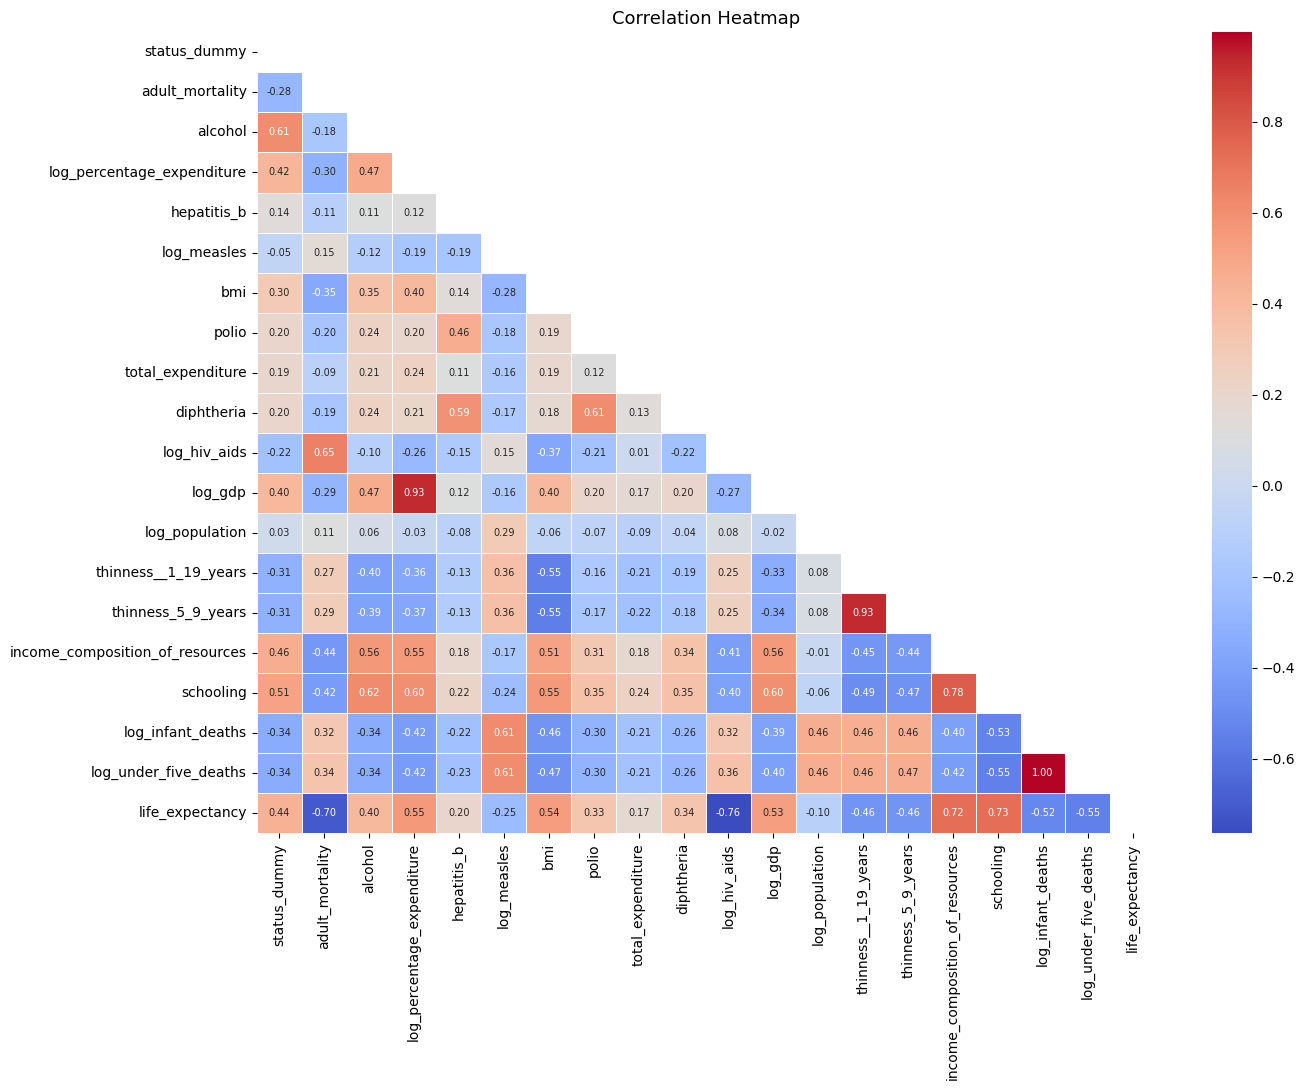

In [9]:
model1_features = ['status_dummy','adult_mortality','alcohol','log_percentage_expenditure',
                   'hepatitis_b','log_measles','bmi','polio','total_expenditure','diphtheria',
                   'log_hiv_aids','log_gdp','log_population','thinness__1_19_years',
                   'thinness_5_9_years','income_composition_of_resources','schooling',
                   'log_infant_deaths','log_under_five_deaths']

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[model1_features + ['life_expectancy']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Linear Regression Models


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

target = 'life_expectancy'

model1_features = ['status_dummy','adult_mortality','alcohol','log_percentage_expenditure',
                   'hepatitis_b','log_measles','bmi','polio','total_expenditure','diphtheria',
                   'log_hiv_aids','log_gdp','log_population','thinness__1_19_years',
                   'thinness_5_9_years','income_composition_of_resources','schooling',
                   'log_infant_deaths','log_under_five_deaths']

model2_features = ['adult_mortality','log_hiv_aids','income_composition_of_resources',
                   'schooling','bmi','status_dummy','log_gdp','diphtheria']

model3_features = ['adult_mortality','income_composition_of_resources','schooling','log_hiv_aids']

results = {}
for name, feats in [('Model 1 (Full)',    model1_features),
                    ('Model 2 (Reduced)', model2_features),
                    ('Model 3 (Minimal)', model3_features)]:
    X = df[feats]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'r2': r2, 'rmse': rmse}
    print(f'{name:25s} | R² = {r2:.4f} | RMSE = {rmse:.4f}')

Model 1 (Full)            | R² = 0.8443 | RMSE = 3.3259
Model 2 (Reduced)         | R² = 0.8432 | RMSE = 3.3376
Model 3 (Minimal)         | R² = 0.8273 | RMSE = 3.5025


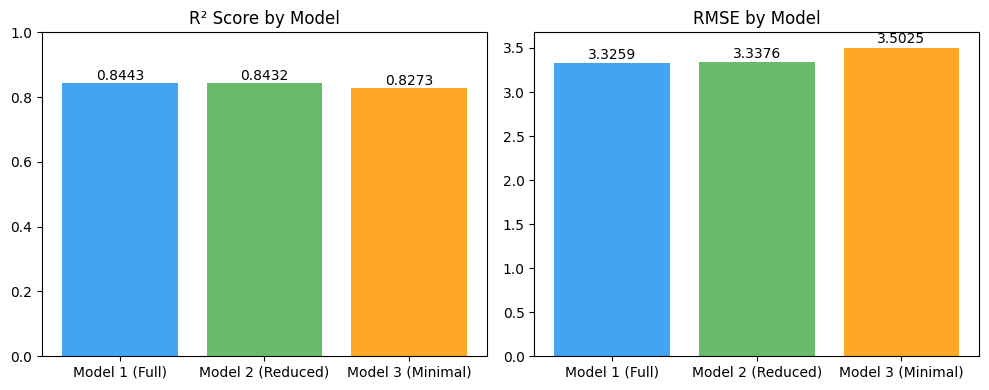

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names  = list(results.keys())
r2s    = [results[n]['r2']   for n in names]
rmses  = [results[n]['rmse'] for n in names]
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].bar(names, r2s, color=colors, alpha=0.85)
axes[0].set_title('R² Score by Model'); axes[0].set_ylim(0, 1)
for i, v in enumerate(r2s): axes[0].text(i, v+0.01, f'{v:.4f}', ha='center')
axes[1].bar(names, rmses, color=colors, alpha=0.85)
axes[1].set_title('RMSE by Model')
for i, v in enumerate(rmses): axes[1].text(i, v+0.05, f'{v:.4f}', ha='center')
plt.tight_layout(); plt.show()

## 9. Model Evaluation & Interpretation

### R² Score
The **R² (coefficient of determination)** measures the proportion of variance in life expectancy that is explained by the model's predictors. An R² of 1.0 is a perfect fit; 0.0 means the model explains nothing beyond the mean.

| Model | R² | Interpretation |
|---|---|---|
| Model 1 (Full, 19 predictors) | **0.8443** | 84.4% of the variance in life expectancy is explained |
| Model 2 (Reduced, 8 predictors) | 0.8432 | 84.3% explained — nearly identical to Model 1 |
| Model 3 (Minimal, 4 predictors) | 0.8273 | 82.7% explained — small drop from fewer predictors |

### RMSE Score
The **RMSE (Root Mean Squared Error)** measures the average prediction error in the same units as the target (years). An RMSE of 3.33 means predictions are off by roughly ±3.3 years on average.

| Model | RMSE (years) | Interpretation |
|---|---|---|
| Model 1 | **3.33** | Predictions off by ~3.3 years on average |
| Model 2 | 3.34 | Nearly identical error to Model 1 |
| Model 3 | 3.50 | Slightly higher error with only 4 predictors |

In the context of life expectancy (ranging ~44–89 years, mean ~69 years), an RMSE of 3.3 years represents roughly **4.8% relative error** — quite reasonable for a global dataset spanning many years and countries.


## 10. Best Model Assessment

**Best model: Model 1 (Full, 19 predictors) — R² = 0.8443, RMSE = 3.33 years**

The best model is **good** by several measures:

- **R² of 0.84** means the model explains 84% of the variation in life expectancy across countries and years — a strong result for a real-world socioeconomic dataset with inherent noise.
- **RMSE of 3.33 years** is clinically and practically meaningful. Predicting life expectancy within ±3–4 years on a global, cross-country dataset is a reasonable level of accuracy given how many country-specific factors (culture, healthcare quality, political stability) are not captured in the data.
- **Feature importance aligns with domain knowledge:** The largest coefficient drivers are `log_under_five_deaths`, `log_hiv_aids`, `income_composition_of_resources`, `schooling`, and `adult_mortality` — all well-established determinants of life expectancy in the public health literature.

**Caveats and limitations:**
- Mild heteroscedasticity and slight tail deviations from normality are present, suggesting the linear model is a reasonable but not perfect fit.
- `infant_deaths` and `under_five_deaths` are highly correlated (multicollinearity), which inflates coefficient variance and makes individual coefficient interpretation unreliable.
- Model 2 (8 predictors) achieves essentially the same R² and RMSE as Model 1, suggesting that **Model 2 may be preferable in practice** due to its simplicity, interpretability, and lower risk of overfitting — even though Model 1 scores marginally higher on the test set.

Overall, the model is a **solid, interpretable baseline** for estimating life expectancy from socioeconomic and health indicators.
